---
tags: [integration, optimization]
---

# qBraidサポート - QBraidExecutor

このページでは、Qamomileの[qBraid](https://www.qbraid.com/)サポートを紹介し、`QBraidExecutor`を使ってQamomileのワークフローを実行する方法を説明します。現状のQamomileはQiskit経由でqBraidと連携するため、基本的な流れは `qkernel` -> `QiskitTranspiler` -> `QBraidExecutor` です。

In [ ]:
# 最新のQamomileをpipからインストールします！
# !pip install "qamomile[qbraid]"

## このノートで扱う内容
このノートは、MaxCutを題材にした `QBraidExecutor`のチュートリアルです。主な目的は、`QBraidExecutor`を設定し、`QiskitTranspiler`で`qkernel`をトランスパイルし、同じexecutorを最適化ループ全体で再利用しながら、最後にqBraidから返るサンプルを確認する流れを示すことです。

## インストール

qBraid連携を使うには、オプションの`qbraid`依存グループを含めてインストールします。

```bash
pip install "qamomile[qbraid]"
```

これにより、Qamomile本体に加えてqBraidパッケージと、そのQiskit連携に必要な依存関係がインストールされます。

In [1]:
import warnings
from collections import defaultdict

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from scipy.optimize import minimize

import qamomile.circuit as qmc
from qamomile.circuit.algorithm.qaoa import qaoa_state
from qamomile.optimization.binary_model.expr import VarType
from qamomile.optimization.binary_model.model import BinaryModel
from qamomile.qbraid import QBraidExecutor
from qamomile.qiskit import QiskitTranspiler

seed = 901
rng = np.random.default_rng(seed)

## qBraidのセットアップ
qBraidは、対応するシミュレータや量子ハードウェアを統一的なインターフェースで扱える実行基盤です。Qamomileでは、`QBraidExecutor`がQiskit回路をqBraidのデバイスへ送信し、リモートジョブの完了を待ち、他のQamomile executorと同じ形式で結果を返します。

このノートでは、最初にexecutorを作成し、それをパラメータ最適化と最後の評価の両方で使い回します。下のwarning filterはこのセットアップ用セルだけに作用するため、既知の`pyqir` runtime warningのみを抑制し、それ以外のwarningには影響しません。

**注意:** 下のセルの `"YOUR_API_KEY"` をご自身のqBraid APIキーに置き換えてください。APIキーは [qBraidアカウントページ](https://account.qbraid.com/) から取得できます。

In [ ]:
device_id = "qbraid:qbraid:sim:qir-sv"
api_key = "YOUR_API_KEY"

if api_key == "YOUR_API_KEY":
    raise ValueError("Replace 'YOUR_API_KEY' with your actual qBraid API key")

with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore",
        message=r"The default runtime configuration for device 'qbraid:qbraid:sim:qir-sv' includes transpilation to program type 'pyqir', which is not registered\.",
        category=RuntimeWarning,
        module=r"qbraid\.runtime\.native\.provider",
    )
    qbraid_executor = QBraidExecutor(
        device_id=device_id,
        api_key=api_key,
    )

## MaxCut例
qBraid executorの準備ができたので、次にMaxCut用のパラメータ付きQAOAプログラムを1つ用意し、最適化の中でqBraidから繰り返しサンプリングします。全体の流れは、グラフ生成 -> Ising モデル化 -> パラメータ付きQAOA qkernel -> Qiskitへのトランスパイル -> qBraidでのサンプリング -> 解の解析、という順番です。

### 問題の構築
`networkx.random_regular_graph` を使って、8ノードの小さな3-正則ランダムグラフをMaxCutのインスタンスとして生成します。このグラフが、後でQAOA回路にエンコードされてqBraid上でサンプリングされる古典入力データになります。図は問題構造を可視化しているだけで、最適化で実際に使うのは`graph`に入っているデータです。

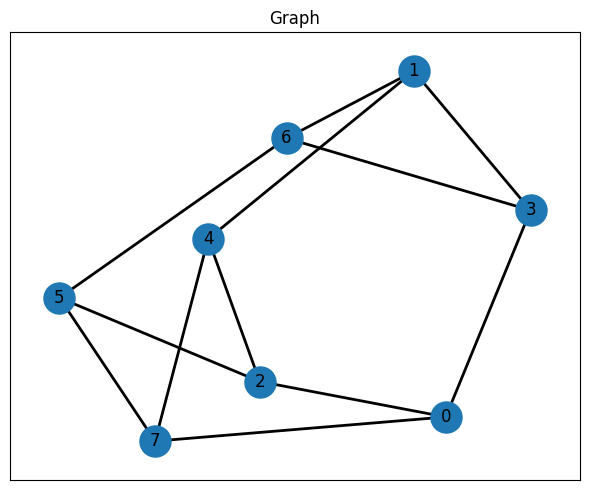

In [3]:
# networkxでランダムグラフを生成
graph = nx.random_regular_graph(d=3, n=8, seed=seed)

# 生成したグラフを可視化
fig, ax = plt.subplots(figsize=(6, 5))
ax.set_title("グラフ")
pos = nx.spring_layout(graph, seed=seed)
nx.draw_networkx(graph, pos, ax=ax, node_size=500, width=2, with_labels=True)
plt.tight_layout()
plt.show()

### Isingハミルトニアンの構築
MaxCutは、両端点が異なるスピン状態にあるときに辺が寄与するIsing最適化問題として書けます。この構成では、各辺が二次の相互作用項を追加し、定数項は「Isingエネルギーを最小化すること」が「cut値を最大化すること」に対応するように目的関数をずらしています。さらに、`normalize_by_rms()`で係数のスケールを揃えておきます。この前処理はQAOA回路でパラメータ最適化を行うための前処理としてしばしば上手く機能します。

In [4]:
quad = {}
linear = {node: 0.0 for node in graph.nodes()}
constant = 0.0

for u, v, data in graph.edges(data=True):
    key = (u, v) if u <= v else (v, u)
    quad[key] = quad.get(key, 0.0) + 1 / 2
    constant -= 1 / 2

spin_model = BinaryModel.from_ising(linear=linear, quad=quad, constant=constant)
spin_model_normalized = spin_model.normalize_by_rms()
spin_model_normalized._expr

BinaryExpr(vartype=<VarType.SPIN: 'SPIN'>, constant=np.float64(-12.0), coefficients={(0,): np.float64(0.0), (1,): np.float64(0.0), (2,): np.float64(0.0), (3,): np.float64(0.0), (4,): np.float64(0.0), (5,): np.float64(0.0), (6,): np.float64(0.0), (7,): np.float64(0.0), (0, 7): np.float64(1.0), (0, 3): np.float64(1.0), (0, 2): np.float64(1.0), (1, 4): np.float64(1.0), (1, 6): np.float64(1.0), (1, 3): np.float64(1.0), (2, 4): np.float64(1.0), (2, 5): np.float64(1.0), (3, 6): np.float64(1.0), (4, 7): np.float64(1.0), (5, 7): np.float64(1.0), (5, 6): np.float64(1.0)})

### QAOA回路の構築
`qaoa_state(...)`はIsingモデルに対するQAOA ansatzを構築し、`qmc.measure(q)`はその状態準備回路を測定ビットを返すsampling qkernelに変換します。その後、量子回路の構造に影響するパラメータだけを先に束縛し、`gammas`と`betas`は変分パラメータとして残したまま`QiskitTranspiler`でトランスパイルします。

In [5]:
@qmc.qkernel
def qaoa_circuit(
    p: qmc.UInt,
    quad: qmc.Dict[qmc.Tuple[qmc.UInt, qmc.UInt], qmc.Float],
    linear: qmc.Dict[qmc.UInt, qmc.Float],
    n: qmc.UInt,
    gammas: qmc.Vector[qmc.Float],
    betas: qmc.Vector[qmc.Float],
) -> qmc.Vector[qmc.Bit]:
    q = qaoa_state(p=p, quad=quad, linear=linear, n=n, gammas=gammas, betas=betas)
    return qmc.measure(q)

In [6]:
transpiler = QiskitTranspiler()
p = 5  # QAOAの層数

executable = transpiler.transpile(
    qaoa_circuit,
    bindings={
        "p": p,
        "quad": spin_model_normalized.quad,
        "linear": spin_model_normalized.linear,
        "n": len(graph.nodes()),
    },
    parameters=["gammas", "betas"],
)

### 最適化
目的関数は、一度に1つの候補パラメータベクトルを評価します。各試行では、`gammas`と`betas`を束縛した実行可能プログラムを`QBraidExecutor`経由でqBraidに送り、得られたビット列サンプルを二値エネルギーに変換して平均を取り、その値を目的関数として使います。外側の古典最適化は`scipy.optimize.minimize(...)`が担当し、各更新を支える測定データはqBraidのサンプリングから得られます。同じexecutorを全反復で使い回します。

In [7]:
# 最適化の履歴を保存するリスト
energy_history = []
# サンプルされたビット列のエネルギーを評価できるように、
# スピンモデルを対応する二値モデルへ変換
binary_model = spin_model.change_vartype(VarType.BINARY)


# 最適化で使う目的関数
def objective_function(params, executable, executor, shots=2000):
    """
    QAOAのパラメータ最適化に用いる目的関数。

    引数:
        params: [gammas, betas] を連結したパラメータ
        executable: コンパイル済みのQAOA回路
        executor: 回路サンプリングに使うexecutor
        shots: 測定ショット数

    戻り値:
        推定平均エネルギー
    """
    p = len(params) // 2
    gammas = params[:p]
    betas = params[p:]

    # 現在のパラメータで回路をサンプリング
    job = executable.sample(
        executor,
        bindings={
            "gammas": gammas,
            "betas": betas,
        },
        shots=shots,
    )
    result = job.result()

    # サンプルされたビット列から平均エネルギーを計算
    energies = []
    for bit_list, counts in result.results:
        energy = binary_model.calc_energy(bit_list)
        for _ in range(counts):
            energies.append(energy)
    energy_avg = np.average(energies)
    energy_history.append(energy_avg)

    return energy_avg

In [8]:
init_params = rng.uniform(low=-np.pi / 4, high=np.pi / 4, size=2 * p)

# 履歴を初期化
energy_history = []

print(f"p={p} 層でQAOAの最適化を開始します...")
print(f"初期パラメータ: gammas={init_params[:p]}, betas={init_params[p:]}")

# COBYLAで最適化
result_opt = minimize(
    objective_function,
    init_params,
    # 目的関数内のサンプリングにQBraidExecutorを使う
    args=(executable, qbraid_executor),
    method="COBYLA",
    options={"disp": True},
)

print("\n最適化後のパラメータ:")
print(f"  gammas: {result_opt.x[:p]}")
print(f"  betas: {result_opt.x[p:]}")
print(f"最終エネルギー: {result_opt.fun:.4f}")

p=5 層でQAOAの最適化を開始します...
初期パラメータ: gammas=[ 0.35076764  0.685864   -0.23260876  0.55643368  0.13513932], betas=[-0.51593692  0.46886025 -0.72964494 -0.30084649 -0.58317504]
Return from COBYLA because the trust region radius reaches its lower bound.
Number of function values = 88   Least value of F = -8.382
The corresponding X is:
[ 1.45802969  0.66918056  0.53326241  1.61889244  0.05980886 -0.08431889
  0.3452794  -0.77868898  0.79537386 -0.66914409]


最適化後のパラメータ:
  gammas: [1.45802969 0.66918056 0.53326241 1.61889244 0.05980886]
  betas: [-0.08431889  0.3452794  -0.77868898  0.79537386 -0.66914409]
最終エネルギー: -8.3820


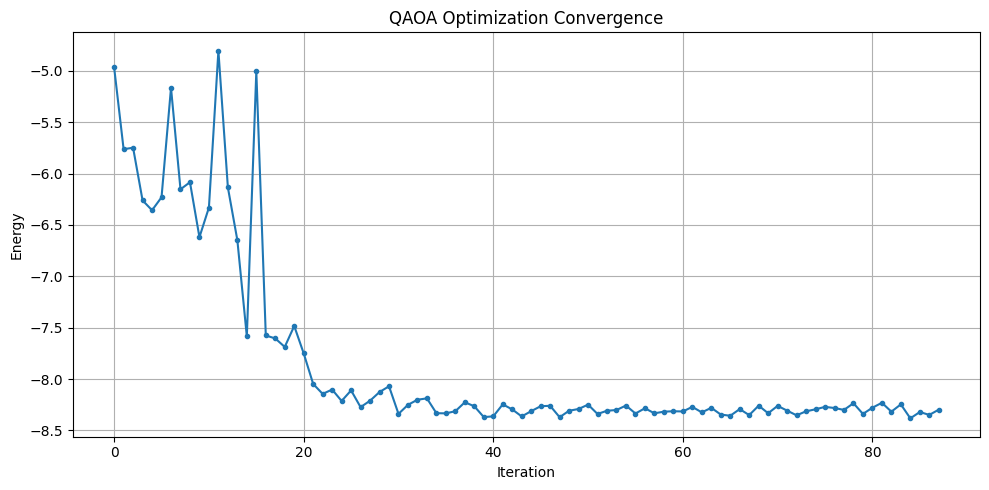

In [20]:
plt.figure(figsize=(10, 5))
plt.plot(energy_history, marker="o", markersize=3)
plt.xlabel("反復回数")
plt.ylabel("エネルギー")
plt.title("QAOA最適化の収束")
plt.grid(True)
plt.tight_layout()
plt.show()

### 評価
最適化が終わったら、最適化済みパラメータでもう一度qBraidを呼び出し、より多くの測定結果を集めます。これにより、最終的なエネルギー分布を確認し、サンプルの中で最も低いエネルギーを与えたビット列を見つけて、それを元のグラフに対するMaxCut解として解釈できます。

In [10]:
# 最適化後のパラメータでサンプリング
optimal_gammas = result_opt.x[:p]
optimal_betas = result_opt.x[p:]

job_final = executable.sample(
    # 最適化で使ったものと同じQBraidExecutorで最終分布をサンプリング
    qbraid_executor,
    bindings={
        "gammas": optimal_gammas,
        "betas": optimal_betas,
    },
    shots=2000,
)
result_final = job_final.result()

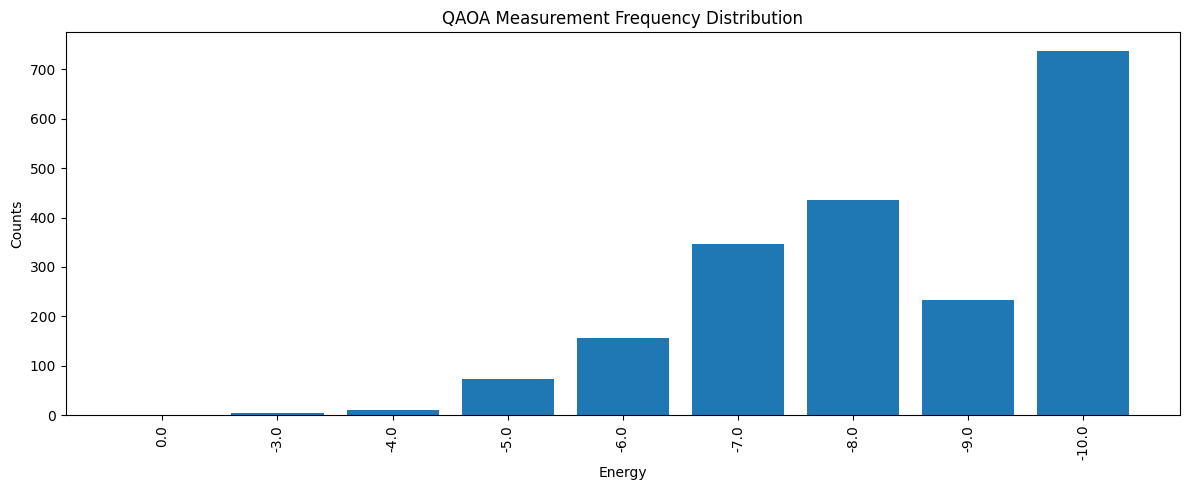

In [11]:
# サンプルされたビット列全体の頻度分布を作成
energy_vs_counts = defaultdict(int)
lowest_energy = float("inf")
best_solution = None
for bit_list, counts in result_final.results:
    energy = binary_model.calc_energy(bit_list)
    energy_vs_counts[energy] += counts
    if energy < lowest_energy:
        lowest_energy = energy
        best_solution = bit_list

# 描画用にエネルギーと頻度を取り出す
energies = list(energy_vs_counts.keys())
counts = list(energy_vs_counts.values())
# 見やすいようにエネルギー順に並べ替え
sorted_indices = np.argsort(energies)[::-1]
counts = np.array(counts)[sorted_indices]
energies = np.array(energies)[sorted_indices]

# 頻度分布を描画
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(energy_vs_counts))
bars = ax.bar(x_pos, counts)

ax.set_xticks(x_pos)
ax.set_xticklabels(energies, rotation=90)
ax.set_xlabel("エネルギー")
ax.set_ylabel("出現回数")
ax.set_title("QAOA測定結果の頻度分布")
plt.tight_layout()
plt.show()

In [21]:
# グラフ上で解を可視化する関数
def get_edge_colors(
    graph, solution: list[int], in_cut_color: str = "r", not_in_cut_color: str = "b"
) -> tuple[list[str], list[str]]:
    cut_set_1 = [node for node, value in enumerate(solution) if value == 1.0]
    cut_set_2 = [node for node in graph.nodes() if node not in cut_set_1]

    edge_colors = []
    for u, v, _ in graph.edges(data=True):
        if (u in cut_set_1 and v in cut_set_2) or (u in cut_set_2 and v in cut_set_1):
            edge_colors.append(in_cut_color)
        else:
            edge_colors.append(not_in_cut_color)
    node_colors = [
        "#2696EB" if node in cut_set_1 else "#EA9b26" for node in graph.nodes()
    ]
    return edge_colors, node_colors


def show_solution(graph, solution, title):
    edge_colors, node_colors = get_edge_colors(graph, solution)
    cut_edges = sum(1 for c in edge_colors if c == "r")
    _, ax = plt.subplots(figsize=(6, 5))
    ax.set_title(f"{title}（カット辺数: {cut_edges}）")
    nx.draw_networkx(
        graph,
        pos,
        ax=ax,
        node_size=500,
        width=3,
        with_labels=True,
        edge_color=edge_colors,
        node_color=node_colors,
    )
    plt.tight_layout()
    plt.show()

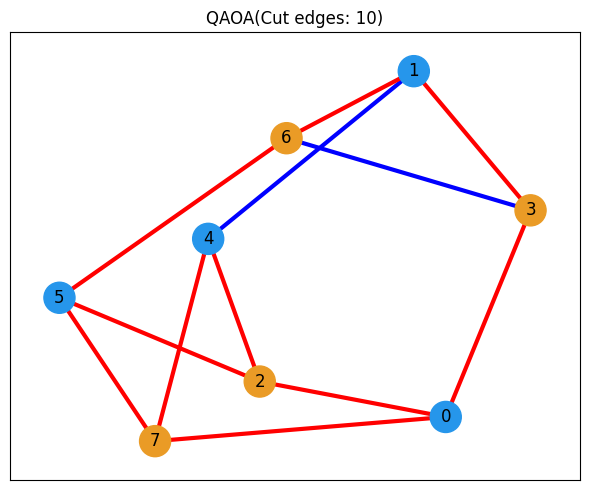

In [22]:
# QAOAで得られた最良の解を可視化
show_solution(graph, best_solution, "QAOA")

## 任意: 古典最適化との比較
メインのqBraidワークフローはここまでです。最後の節では、[JijModeling](https://jij-inc-jijmodeling-tutorials-ja.readthedocs-hosted.com/ja/latest/introduction.html) と `OMMXPySCIPOptAdapter` を使った古典最適化と比較します。これにより、同じMaxCutインスタンスに対して得られたQAOAの結果がどの程度良いかを判断しやすくなります。

In [14]:
import jijmodeling as jm
from ommx_pyscipopt_adapter import OMMXPySCIPOptAdapter

In [15]:
# JijModelingでMaxCut問題を定義
problem = jm.Problem("Maxcut", sense=jm.ProblemSense.MAXIMIZE)


@problem.update
def _(problem: jm.DecoratedProblem):
    V = problem.Dim()
    E = problem.Graph()
    x = problem.BinaryVar(shape=(V,))

    obj = (
        E.rows()
        .map(lambda e: 1 / 2 * (1 - (2 * x[e[0]] - 1) * (2 * x[e[1]] - 1)))
        .sum()
    )
    problem += obj


problem

Problem(name="Maxcut", sense=MAXIMIZE, objective=sum(E.rows().map(lambda (e: Tuple[natural, natural]): 0.5 * (1 - (2 * x[e[0]] - 1) * (2 * x[e[1]] - 1)))), constraints=[])

In [16]:
# グラフデータからOMMXインスタンスを作成
V = graph.number_of_nodes()
E = graph.edges()
data = {"V": V, "E": E}
print(data)
instance = problem.eval(data)

{'V': 8, 'E': EdgeView([(0, 7), (0, 3), (0, 2), (1, 4), (1, 6), (1, 3), (2, 4), (2, 5), (3, 6), (4, 7), (5, 7), (5, 6)])}


In [17]:
# OMMXPySCIPOptAdapterで問題を解く
scip_solution = OMMXPySCIPOptAdapter.solve(instance)
scip_solution_entries = [bit for bit in scip_solution.state.entries.values()]
print(f"SCIPの解: {scip_solution_entries}")

SCIPの解: [0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0]


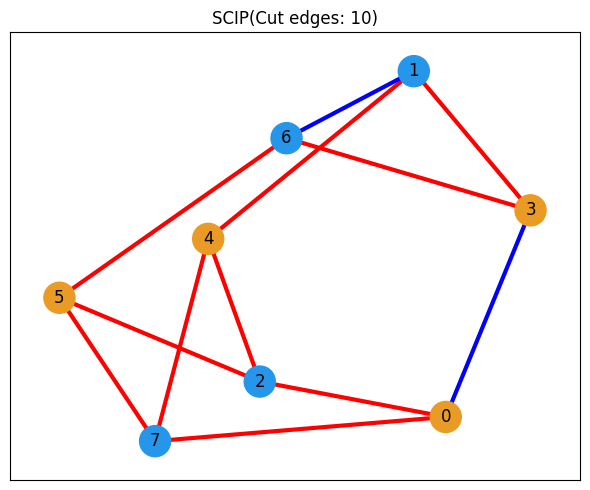

In [23]:
# SCIPで得られた解を可視化
show_solution(graph, scip_solution_entries, "SCIP")

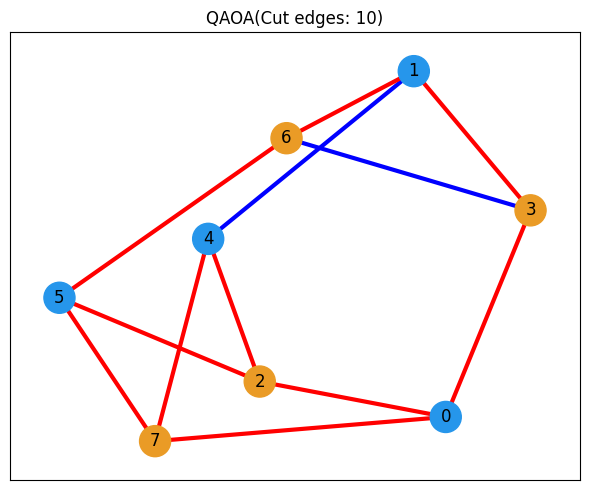

In [24]:
# 比較のためにQAOAの最良解をもう一度可視化
show_solution(graph, best_solution, "QAOA")